In [2]:
# 1. Setup & Imports

!pip install mlxtend --quiet  # run this once in Colab / Jupyter; remove in plain .py if already installed

import pandas as pd
import numpy as np

from mlxtend.frequent_patterns import apriori, association_rules



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
# 2. Load the dataset

DATA_PATH = "uci_combined_students.csv"  # make sure the file is in your working directory
#DATA_PATH = "merged_common_students.csv"


df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()


Shape: (1044, 34)

Columns:
 ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'course']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Mathematics


In [4]:
# 3. Basic exploration

print(df.info())
print("\nDescribe numeric columns:\n")
print(df.describe())

print("\nValue counts for 'course':")
print(df['course'].value_counts())

print("\nValue counts for 'G3' (final grade):")
print(df['G3'].value_counts().sort_index())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [5]:
# 4. Feature engineering / binning

df_prep = df.copy()

# ---- Grades: low / medium / high ----
def bin_grade(g):
    if g <= 9:
        return "low"
    elif g <= 14:
        return "medium"
    else:
        return "high"

df_prep["G1_cat"] = df_prep["G1"].apply(bin_grade)
df_prep["G2_cat"] = df_prep["G2"].apply(bin_grade)
df_prep["G3_cat"] = df_prep["G3"].apply(bin_grade)

# ---- Alcohol consumption (Dalc, Walc: 1–5) ----
alc_bins = [0, 1, 2, 3, 5]
alc_labels = ["very_low", "low", "medium", "high"]

df_prep["Dalc_cat"] = pd.cut(df_prep["Dalc"], bins=alc_bins, labels=alc_labels, right=True)
df_prep["Walc_cat"] = pd.cut(df_prep["Walc"], bins=alc_bins, labels=alc_labels, right=True)

# ---- Studytime (1–4) → very_low, low, medium, high ----
study_bins = [0, 1, 2, 3, 4]
study_labels = ["very_low", "low", "medium", "high"]
df_prep["studytime_cat"] = pd.cut(df_prep["studytime"], bins=study_bins, labels=study_labels, right=True)

# ---- Absences (0–93) → low, medium, high (you can tune thresholds) ----
df_prep["absences_cat"] = pd.cut(
    df_prep["absences"],
    bins=[-1, 5, 15, 100],
    labels=["low", "medium", "high"]
)

# ---- Failures (0–3+) ----
def bin_failures(f):
    if f == 0:
        return "0"
    elif f == 1:
        return "1"
    else:
        return ">=2"

df_prep["failures_cat"] = df_prep["failures"].apply(bin_failures)

# (Optional) you can also bin age if you want
def bin_age(a):
    if a <= 16:
        return "15-16"
    elif a <= 18:
        return "17-18"
    else:
        return "19+"

df_prep["age_cat"] = df_prep["age"].apply(bin_age)

df_prep[["G1", "G1_cat", "G2", "G2_cat", "G3", "G3_cat", "Dalc", "Dalc_cat", "Walc", "Walc_cat"]].head()


,G1,G1_cat,G2,G2_cat,G3,G3_cat,Dalc,Dalc_cat,Walc,Walc_cat
0,5,low,6,low,6,low,1,very_low,1,very_low
1,5,low,5,low,6,low,1,very_low,1,very_low
2,7,low,8,low,10,medium,2,low,3,medium
3,15,high,14,medium,15,high,1,very_low,1,very_low
4,6,low,10,medium,10,medium,1,very_low,2,low


In [6]:
# 5. Select columns for association mining

cols_for_rules = [
    "school",
    "sex",
    "age_cat",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "studytime_cat",
    "failures_cat",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic",
    "Dalc_cat",
    "Walc_cat",
    "absences_cat",
    "G1_cat",
    "G2_cat",
    "G3_cat",
    "course",
]

df_rules = df_prep[cols_for_rules].copy()
df_rules.head()


,school,sex,age_cat,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,...,higher,internet,romantic,Dalc_cat,Walc_cat,absences_cat,G1_cat,G2_cat,G3_cat,course
0,GP,F,17-18,U,GT3,A,at_home,teacher,course,mother,...,yes,no,no,very_low,very_low,medium,low,low,low,Mathematics
1,GP,F,17-18,U,GT3,T,at_home,other,course,father,...,yes,yes,no,very_low,very_low,low,low,low,low,Mathematics
2,GP,F,15-16,U,LE3,T,at_home,other,other,mother,...,yes,yes,no,low,medium,medium,low,low,medium,Mathematics
3,GP,F,15-16,U,GT3,T,health,services,home,mother,...,yes,yes,yes,very_low,very_low,low,high,medium,high,Mathematics
4,GP,F,15-16,U,GT3,T,other,other,home,father,...,yes,no,no,very_low,low,low,low,medium,medium,Mathematics


In [7]:
# 6. Convert to one-hot encoded (transaction) format

# Make sure everything is string/categorical
df_rules = df_rules.astype(str)

# get_dummies will create columns like 'sex_F', 'sex_M', 'G3_cat_high', etc.
df_ohe = pd.get_dummies(df_rules)

print("One-hot encoded shape:", df_ohe.shape)
df_ohe.head()


One-hot encoded shape: (1044, 75)


,school_GP,school_MS,sex_F,sex_M,age_cat_15-16,age_cat_17-18,age_cat_19+,address_R,address_U,famsize_GT3,...,G1_cat_low,G1_cat_medium,G2_cat_high,G2_cat_low,G2_cat_medium,G3_cat_high,G3_cat_low,G3_cat_medium,course_Mathematics,course_Portuguese
0,True,False,True,False,False,True,False,False,True,True,...,True,False,False,True,False,False,True,False,True,False
1,True,False,True,False,False,True,False,False,True,True,...,True,False,False,True,False,False,True,False,True,False
2,True,False,True,False,True,False,False,False,True,False,...,True,False,False,True,False,False,False,True,True,False
3,True,False,True,False,True,False,False,False,True,True,...,False,False,False,False,True,True,False,False,True,False
4,True,False,True,False,True,False,False,False,True,True,...,True,False,False,False,True,False,False,True,True,False


In [8]:
# 7. Run Apriori (with built-in filtering)

from mlxtend.frequent_patterns import apriori

# --- (optional but recommended) drop very rare dummy columns first ---
min_col_support = 0.03        # column must be 3% '1' to be kept
row_count = len(df_ohe)
cols_to_keep = [c for c in df_ohe.columns if df_ohe[c].sum() >= min_col_support * row_count]
df_ohe_reduced = df_ohe[cols_to_keep]

print("Original columns:", df_ohe.shape[1])
print("Reduced columns:", df_ohe_reduced.shape[1])

# --- run Apriori on the reduced matrix ---
frequent_itemsets = apriori(
    df_ohe_reduced,
    min_support=0.10,         # appears in at least 10% of transactions
    use_colnames=True,
    max_len=2                 # only 1- and 2-itemsets (keeps runtime small)
)

# add length of itemsets
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

# filter again just to be safe (can tweak thresholds)
frequent_itemsets = frequent_itemsets[
    (frequent_itemsets["length"] <= 2) &
    (frequent_itemsets["support"] >= 0.10)
].copy()

print("Number of frequent itemsets after filtering:", len(frequent_itemsets))
frequent_itemsets.sort_values("support", ascending=False).head(10)


Original columns: 75
Reduced columns: 75
Number of frequent itemsets after filtering: 1217


,support,itemsets,length
39,0.914751,(higher_yes),1
29,0.886015,(schoolsup_no),1
11,0.884100,(Pstatus_T),1
27,0.824713,(failures_cat_0),1
504,0.809387,"(higher_yes, Pstatus_T)",2
872,0.803640,"(higher_yes, schoolsup_no)",2
38,0.799808,(nursery_yes),1
41,0.792146,(internet_yes),1
33,0.789272,(paid_no),1
495,0.785441,"(Pstatus_T, schoolsup_no)",2


In [9]:
# 8. Generate association rules from frequent itemsets

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6  # minimum confidence 60%
)

# Sort by confidence or lift
rules_sorted = rules.sort_values(["lift", "confidence"], ascending=False)

print("Number of rules:", len(rules_sorted))
rules_sorted.head(10)


Number of rules: 924


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
899,(G1_cat_high),(G2_cat_high),0.139847,0.158046,0.112069,0.801370,5.070486,1.0,0.089967,4.238803,0.933299,0.603093,0.764084,0.755230
900,(G2_cat_high),(G1_cat_high),0.158046,0.139847,0.112069,0.709091,5.070486,1.0,0.089967,2.956777,0.953473,0.603093,0.661794,0.755230
913,(G2_cat_high),(G3_cat_high),0.158046,0.195402,0.156130,0.987879,5.055615,1.0,0.125248,66.379310,0.952784,0.791262,0.984935,0.893449
914,(G3_cat_high),(G2_cat_high),0.195402,0.158046,0.156130,0.799020,5.055615,1.0,0.125248,4.189235,0.997020,0.791262,0.761293,0.893449
901,(G1_cat_high),(G3_cat_high),0.139847,0.195402,0.123563,0.883562,4.521757,1.0,0.096237,6.910074,0.905475,0.583710,0.855284,0.757957
902,(G3_cat_high),(G1_cat_high),0.195402,0.139847,0.123563,0.632353,4.521757,1.0,0.096237,2.339617,0.967996,0.583710,0.572580,0.757957
915,(G3_cat_low),(G2_cat_low),0.220307,0.278736,0.202107,0.917391,3.291260,1.0,0.140700,8.731095,0.892870,0.680645,0.885467,0.821239
916,(G2_cat_low),(G3_cat_low),0.278736,0.220307,0.202107,0.725086,3.291260,1.0,0.140700,2.836135,0.965201,0.680645,0.647407,0.821239
905,(G3_cat_low),(G1_cat_low),0.220307,0.286398,0.183908,0.834783,2.914759,1.0,0.120813,4.319167,0.842534,0.569733,0.768474,0.738462
906,(G1_cat_low),(G3_cat_low),0.286398,0.220307,0.183908,0.642140,2.914759,1.0,0.120813,2.178770,0.920568,0.569733,0.541025,0.738462


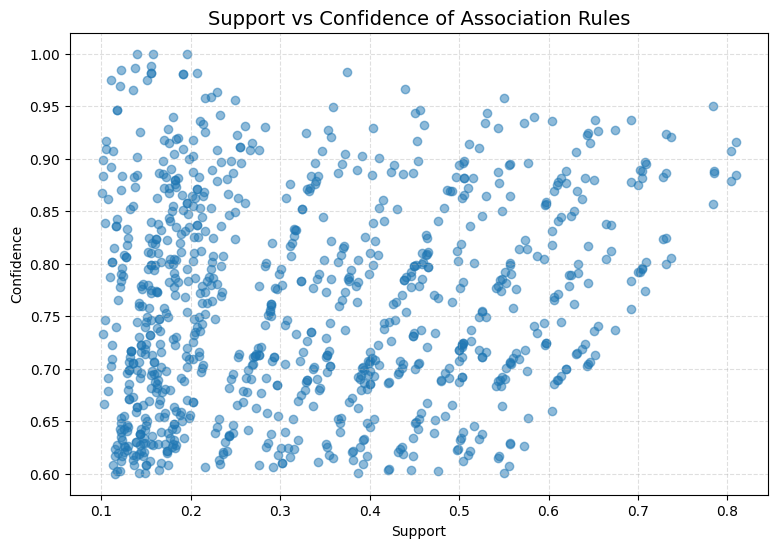

In [10]:
# Plot 1: Support vs Confidence
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))
plt.scatter(rules_sorted["support"], rules_sorted["confidence"], alpha=0.5)
plt.title("Support vs Confidence of Association Rules", fontsize=14)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


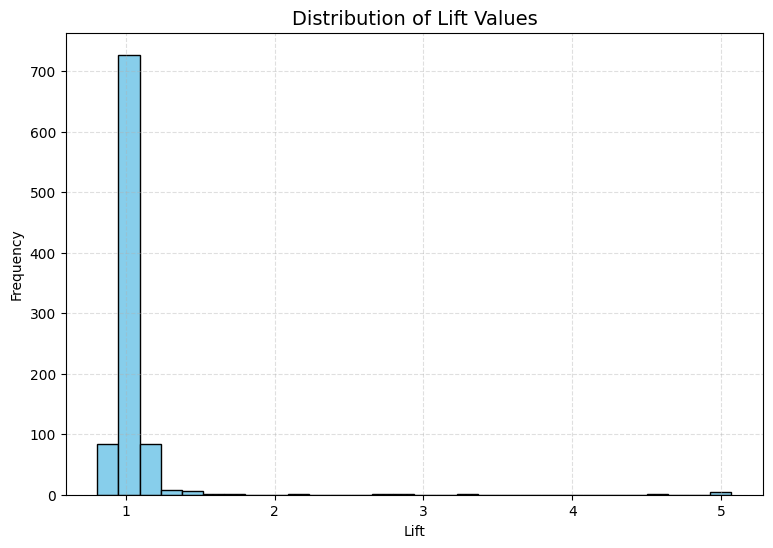

In [11]:
# Plot 2: Lift Distribution
plt.figure(figsize=(9,6))
plt.hist(rules_sorted["lift"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Lift Values", fontsize=14)
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


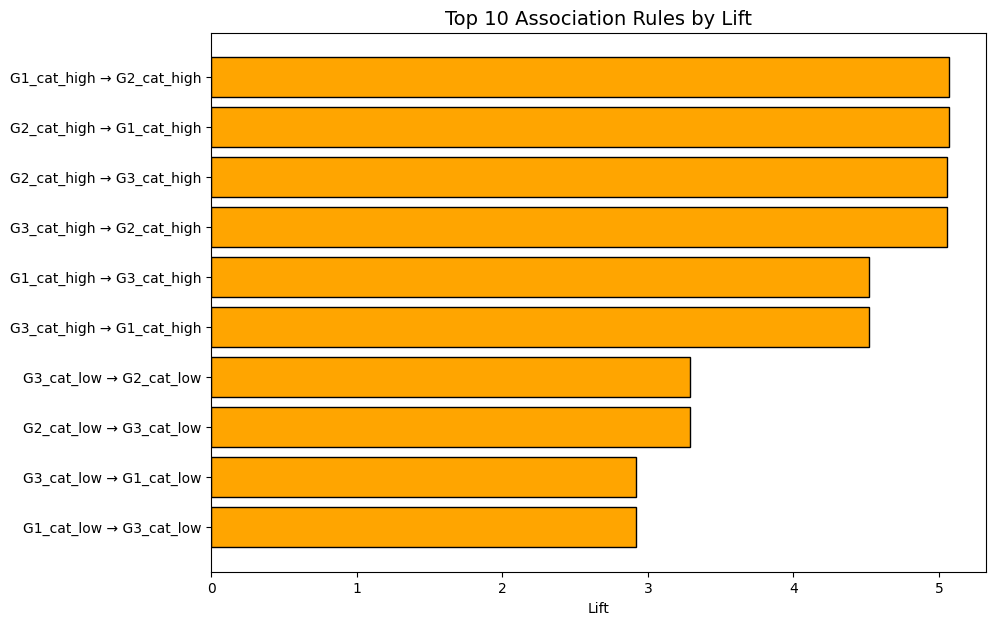

In [12]:
# Plot 3: Top 10 Rules by Lift
top10 = rules_sorted.head(10)

plt.figure(figsize=(10,7))
plt.barh(
    range(len(top10)),
    top10["lift"],
    color="orange",
    edgecolor="black"
)
plt.yticks(range(len(top10)), [
    f"{list(a)[0]} → {list(c)[0]}"
    for a, c in zip(top10["antecedents"], top10["consequents"])
])
plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift", fontsize=14)
plt.gca().invert_yaxis()
plt.show()


In [13]:
# 9. Filter rules where the consequent involves final grade (G3_cat)

def has_G3_consequent(row):
    return any("G3_cat" in str(item) for item in row["consequents"])

rules_G3 = rules_sorted[rules_sorted.apply(has_G3_consequent, axis=1)].copy()

# Show top rules related to final grade
rules_G3[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)


,antecedents,consequents,support,confidence,lift
913,(G2_cat_high),(G3_cat_high),0.156130,0.987879,5.055615
901,(G1_cat_high),(G3_cat_high),0.123563,0.883562,4.521757
916,(G2_cat_low),(G3_cat_low),0.202107,0.725086,3.291260
906,(G1_cat_low),(G3_cat_low),0.183908,0.642140,2.914759
918,(G2_cat_medium),(G3_cat_medium),0.505747,0.897959,1.536835
910,(G1_cat_medium),(G3_cat_medium),0.465517,0.811352,1.388609
923,(course_Portuguese),(G3_cat_medium),0.400383,0.644068,1.102306
138,(age_cat_15-16),(G3_cat_medium),0.290230,0.637895,1.091741
481,(guardian_father),(G3_cat_medium),0.147510,0.633745,1.084639
744,(nursery_no),(G3_cat_medium),0.125479,0.626794,1.072743


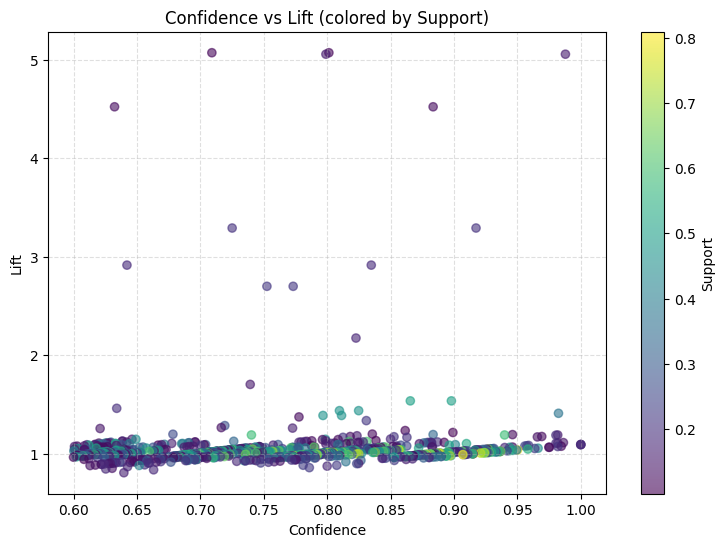

In [14]:
# Plot 4: Heatmap-style scatter (confidence vs lift)
plt.figure(figsize=(9,6))
plt.scatter(
    rules_sorted["confidence"],
    rules_sorted["lift"],
    c=rules_sorted["support"],
    cmap='viridis',
    alpha=0.6
)
plt.colorbar(label="Support")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift (colored by Support)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [15]:
# 10. Rules that predict high final grade (G3_cat_high)

def is_G3_high(row):
    return any("G3_cat_high" in str(item) for item in row["consequents"])

rules_G3_high = rules_sorted[rules_sorted.apply(is_G3_high, axis=1)].copy()

rules_G3_high[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(20)


,antecedents,consequents,support,confidence,lift
913,(G2_cat_high),(G3_cat_high),0.156130,0.987879,5.055615
901,(G1_cat_high),(G3_cat_high),0.123563,0.883562,4.521757


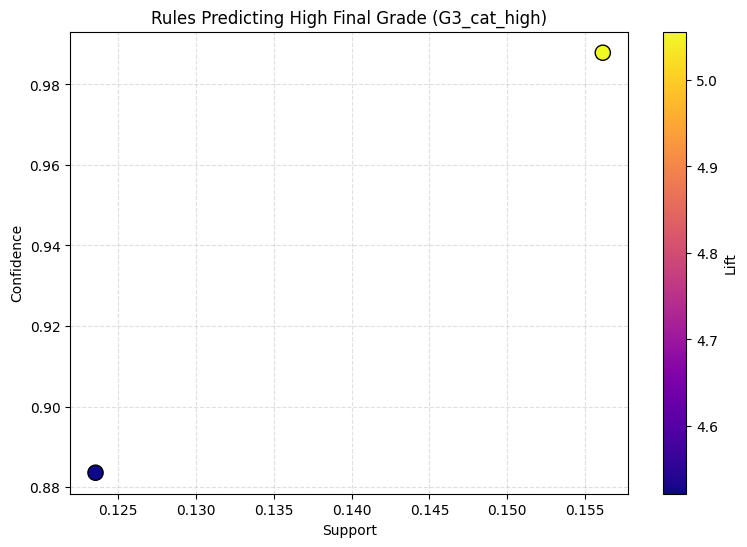

In [16]:
# Plot 5: High Grade (G3_cat_high) Rules - Scatter Plot
plt.figure(figsize=(9,6))
plt.scatter(
    rules_G3_high["support"],
    rules_G3_high["confidence"],
    c=rules_G3_high["lift"],
    cmap="plasma",
    s=120,
    edgecolor="black"
)
plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Rules Predicting High Final Grade (G3_cat_high)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()